In [1]:
import paicos as pa
import numpy as np
import turbocluster as tc

pa.settings.strict_units = False
# A snapshot object
snap = pa.Snapshot('/llust21/cosmo-plasm/zoom-simulations-arepo2/halo_0003/tng/zoom12/output', 
                   305, basename='snapshot')
center = snap.Cat.Group['GroupPos'][0]
widths = np.array([3e2, 3e2, 3e2], dtype=float)




In [2]:
import cmasher as cmr
%matplotlib widget
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize

gray = plt.cm.gray(np.linspace(0,1,10))
reds = plt.cm.Reds_r(np.linspace(0,1,10))


In [3]:
weight=None
# filter_type = 'gaussian'
filter_type = 'mean'
arepo_length = snap.length.uq
filter_length = 10*arepo_length

In [4]:
orientation = pa.Orientation(normal_vector=[1,-2,1], 
                            perp_vector1=[0,0.2,-0.3])

In [5]:

sf = tc.SmoothingFilter(snap, center, widths, npix=128, orientation=orientation, 
                        search_radius=None)

Attempting to get derived variable: 0_Volume...	[DONE]



In [6]:
smooth_den, turb_den = tc.extract_turbulent_var(snap, sf, '0_Density', 
                                                   filter_length=filter_length, 
                                              weight=weight, filter_type=filter_type)

min/max/avg occupancy cartesian tiling 0 / 20 / 1.86


In [7]:
widths_slicer = widths.copy()
widths_slicer[2] = 0.
slicer = pa.Slicer(snap, center, widths_slicer, orientation, npix=2048)
extent = slicer.centered_extent.to('Mpc')

In [8]:
dens_tot = slicer.slice_variable('0_Density')
dens_bulk = slicer.slice_variable(smooth_den)
dens_turb = slicer.slice_variable(turb_den)

Text(0.5, 0.95, 'Density field (orientation)')

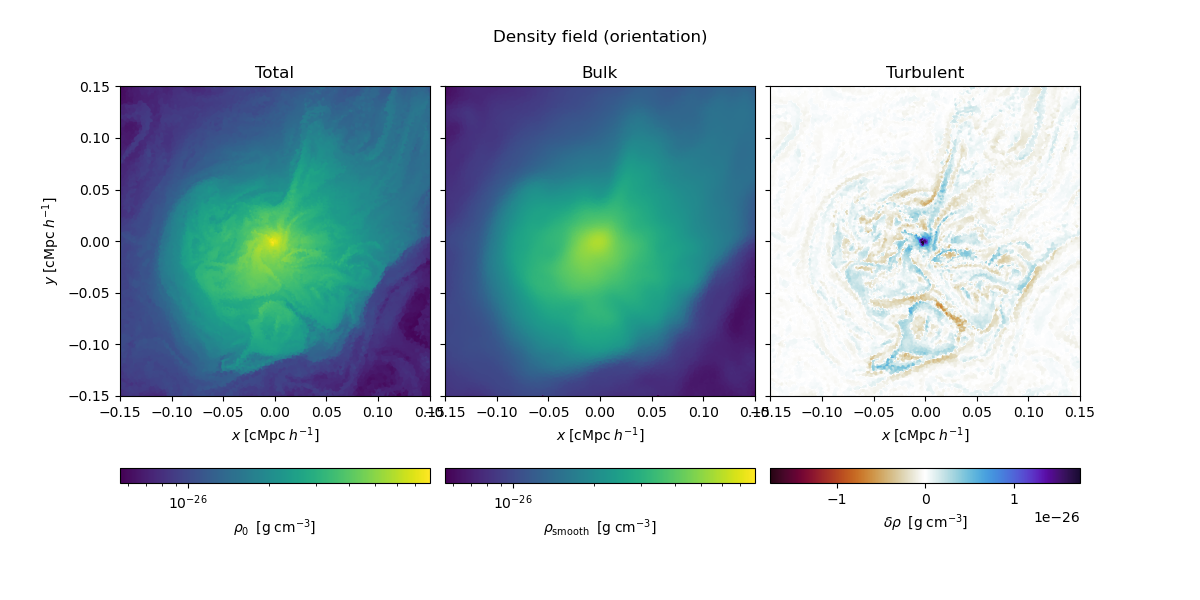

In [9]:

dens_tot = dens_tot.to_physical.cgs
dens_bulk = dens_bulk.to_physical.cgs
dens_turb = dens_turb.to_physical.cgs

vmin = dens_tot.value.min()
vmax = dens_tot.value.max()
norm = LogNorm(vmin=vmin,vmax=vmax)


vmin = -0.8*dens_turb.value.max()
vmax = 0.8*dens_turb.value.max()
norm1 = Normalize(vmin=vmin,vmax=vmax)
cmap = cmr.fusion

fig, axes = plt.subplots(1,3, figsize=(12,6),sharex=True, sharey=True)

im1 = axes[0].imshow(
    dens_tot.value, origin='lower', norm=norm,extent=extent.value)
im2 = axes[1].imshow(
    dens_bulk.value, origin='lower', norm=norm,extent=extent.value)
im3 = axes[2].imshow(
    dens_turb.value, origin='lower', norm=norm1,cmap=cmap,extent=extent.value)

axes[0].set_title('Total')
axes[1].set_title('Bulk')
axes[2].set_title('Turbulent')

for i in range(3):
    axes[i].set_xlabel(extent.label('x'))

axes[0].set_ylabel(extent.label('y'))



cbar = fig.colorbar(im1, orientation='horizontal')
cbar.set_label(dens_tot.label('\\rho_0'))

cbar = fig.colorbar(im2, orientation='horizontal')
cbar.set_label(dens_tot.label('\\rho_{\mathrm{smooth}}'))

cbar = fig.colorbar(im3, orientation='horizontal')
cbar.set_label(dens_tot.label('\\delta \\rho '))



fig.subplots_adjust(top=0.9,
bottom=0.1,
left=0.10,
right=0.90,
hspace=0.0,
wspace=0.05)

fig.suptitle('Density field (orientation)',y=0.95)
# plt.savefig('../plots/density_field.pdf')